In [9]:
import numpy as np
from pprint import pprint
from matplotlib import pyplot as plt

# KickerControl

**[04-11-2024]:** Here's an update of the Kicker Control scripts I've been working on for beam steering. In the future, the logical flow of the module may change due to integration with Karabo and DOOCS. I've tried to preempt those changes and will explain some of the design considerations.

The `kickercontrol` package is designed to enable photon beam steering at the European XFEL. It provides the necessary tools to facilitate the operation of beam steering instrumentation at the European XFEL on the inter-train and intra-train timescales. An overview of the core structure of the package is presented below:

<div align="center">

![kickerControl Package Structure](./img/kickercontrol_IO.png)

</div>

**[04-11-2024]:** At the moment, the device sits completely separate from Karabo as a matter of priorities. The `DACSignalGenerator` and `Scan` method have thus far been designed with the intent to interface with the `Karabo` scene.

## `KickerDevice()`

[``device.py``](../kickercontrol/device.py) is a simple `pydoocs` interface to the KL kickers located in the XTL. Each `KickerDevice` has the ability to read and write the DAC channel of a physical kicker device. Each DAC channel takes a 16-bit signed integer, which corresponds to a ±1V input signal. The input signal yields a proportional kicker current. The strength of the kicker current varies between kickers, as does the signal duration and interval. The table of suitable kickers, their direction, and their current (proportional to kick strength) are listed below:

<div align="center">

**Table 1: Kicker Devices for Photon Beam Steering.** Each kicker is named with respect to its physical location. The maximum gradient of the signal is limited by the kicker rise time of 20 A/µs. Amplitude stability is proportional to kick strength: ~ 3e-04 dA/A.

| Kicker   | Notes                   | Current      |
|----------|-------------------------|--------------|
| KMX1938  | Horizontal Compensation | ± 300 A      |
| KNY1938  | Vertical Compensation   | ± 50 A       |
| KMX1965  | Horizontal Compensation | ± 300 A      |
| KNY1965  | Vertical Compensation   | ± 50 A       |
| KL2005   | Vertical Kick           | ± 15 A       |

</div>

Each `KickerDevice` initialises a kicker DAC channel for read/write.

### Reading a `KickerDevice`

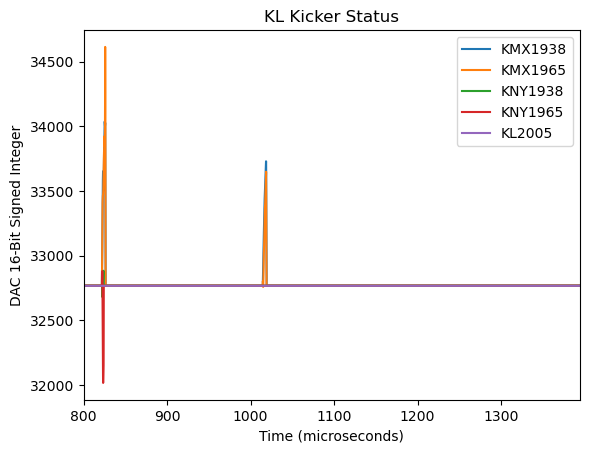

In [2]:
from kickercontrol.device import (KMX1938, KMX1965, KNY1938,
                                  KNY1965,KL2005)

kicker_devices = [KMX1938, KMX1965, KNY1938,
                  KNY1965, KL2005]

fig, ax = plt.subplots(1,1)

ax.set_xlabel("Time (microseconds)")
ax.set_ylabel("DAC 16-Bit Signed Integer")
ax.set_title("KL Kicker Status")

ax.set_xlim(800, 800+2700*220e-03)

for kicker in kicker_devices:
    
    k = kicker()
    time, signal = k.read_dac().T

    ax.plot(time, signal, label = k.__name__)

_ = ax.legend()
plt.show()



### Writing a `KickerDevice`

**[04-11-2024]:** We don't have permission to write that signal to the kicker - and maybe for good reason. For now, this function will only be possible from xfel-oper desktop nodes. In the future, the `write_dac()` function will be modified to interface w/ `Karabo Bridge`

In [3]:
from kickercontrol.device import (KMX1938, KMX1965, KNY1938,
                                  KNY1965,KL2005)

kicker_devices = [KMX1938, KMX1965, KNY1938,
                  KNY1965, KL2005]

### All signals have length 65535 - however their intervals change
signal_length = 65535

for kicker in kicker_devices:
    
    k = kicker()

    print(f"DAC interval: {k.get_signal_interval} ns")

    ### Generate an arbitrary signal
    signal = np.random.rand(signal_length)
    try:
        k.write_dac(signal)
    except Exception as e:
        pass

    break


DAC interval: 0.11076757201543068 ns


## `DAQSignalGenerator()`

The [``signal.py``](../kickercontrol/signal.py) module generates arbitrary signals that are suitable to be written to a specified `KickerDevice`. The `DACSignalGenerator` class was written with the intent of supporting underlying a `Karabo GUI` and has a strange input structure as a conseqeuence. 

**[04-11-2024]:** For reference, inspiration for the structure of the device and future GUI come from digital synthesiser I used in a past life. Below is Serum, a paticularly powerful wavetable synth, with some annotations on the components which we will recreate in our own device.


<div align="center">

![kickerControl Package Structure](./img/synthesiser_concept.png)

</div>




 `DACSignalGenerator` takes a `KickerDevice` as its input, and requires that a `beamline` be specified using its [bunch pattern identifier](https://accelconf.web.cern.ch/fel2019/papers/wep008.pdf). By specifying a `beamline` we can **assert** that the start and end times of the signal are within the bounds of the specified beam region for that beamline. Upon initialising these classes, the `DACSignalGenerator` generates a signal of duration equal to:

<div align="center">

```python
signal_duration = KickerDevice().get_signal_interval*65535
```
</div>


In addition to specifying a `KickerDevice` and `beamline`, the `DACSignalGenerator` takes as its inputs a supported `oscillator` and `**kwargs**` corresponding to the oscillator variables. The oscillators, along with instructions on adding more oscillators in the future are located in [``__base__.py``](../kickercontrol/__base__.py).Each `oscillator` in `__base__.py` generates a signal of length equal to the above DAC signal duration, and writes values to the `KickerDevice` only in the range corresponding to the beam-region of the specified beamline.

The units of the generated signal are in V - corresponding the the \pm 1V range of the DAC, and are converted to 16-bit signed integer internally.

The current beam-regions can plotted using the [``timing.py``](../kickercontrol/signal.py) module:


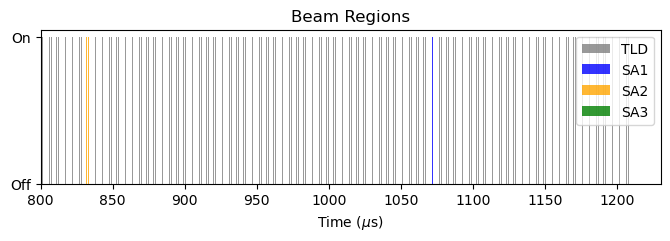

In [4]:
from kickercontrol.timing import plot_beam_regions
plot_beam_regions()

Each oscillator maps up to 8 variable slots to a waveform. Mapping of the variable slots `V0-V7` to properties of the waveform, default values of these variables and the latex expression of these waveforms are all properties of the `oscillator`. For example

In [5]:
from kickercontrol.signal import DACSignalGenerator

dac_generator = DACSignalGenerator(KL2005(), beamline = '2', oscillator='sin')

print(dac_generator.oscillator.variables)
print(dac_generator.oscillator.default_values)
print(f'${dac_generator.oscillator.get_latex_expression()}$')


{'V0': 'start', 'V1': 'end', 'V2': 'offset', 'V3': 'amplitude', 'V4': 'frequency', 'V5': 'phase'}
{'V0': 795, 'V1': 1200, 'V2': 0, 'V3': 1, 'V4': 0.0024691358024691358, 'V5': 0}
$V_3 \sin(2 \pi V_4 t) + V_2, \text{for } t \in [V_0, V_1]$


For ease, i've just included the mapping of all oscillators below:

| Oscillator           | Equation                                                                                     | `__base__` Method                              | Variable Mapping and Default Values                                                                                                          |
|----------------------|----------------------------------------------------------------------------------------------|------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------|
| Line                 | $$ V_2 \text{ for } t \in [V_0, V_1] $$                                                      | `kickercontrol.__base__.LineSignal`            | `V0`: start (default: 795), `V1`: end (default: 1200), `V2`: offset (default: 0)                                                             |
| Sin                  | $$ V_3 \sin(2 \pi V_4 t) + V_2, \text{ for } t \in [V_0, V_1] $$                             | `kickercontrol.__base__.SinSignal`             | `V0`: start (default: 795), `V1`: end (default: 1200), `V2`: offset (default: 0), `V3`: amplitude (default: 1), `V4`: frequency (default: 0.0024691358024691358), `V5`: phase (default: 0) |
| Cos                  | $$ V_3 \cos(2 \pi V_4 t) + V_2, \text{ for } t \in [V_0, V_1] $$                             | `kickercontrol.__base__.CosSignal`             | `V0`: start (default: 795), `V1`: end (default: 1200), `V2`: offset (default: 0), `V3`: amplitude (default: 1), `V4`: frequency (default: 0.0024691358024691358), `V5`: phase (default: 0) |
| Square               | $$ V_3 \text{square}(2 \pi V_4 t, \text{duty}=V_5) + V_2, \text{ for } t \in [V_0, V_1] $$   | `kickercontrol.__base__.SquareSignal`          | `V0`: start (default: 795), `V1`: end (default: 1200), `V2`: offset (default: 0), `V3`: amplitude (default: 1), `V4`: frequency (default: 1), `V5`: duty (default: 0.5) |
| Triangle             | $$ V_3 \text{triangle}(2 \pi V_4 t) + V_2, \text{ for } t \in [V_0, V_1] $$                  | `kickercontrol.__base__.TriangleSignal`        | `V0`: start (default: 795), `V1`: end (default: 1200), `V2`: offset (default: 0), `V3`: amplitude (default: 1), `V4`: frequency (default: 1) |
| Ramp                 | $$ \text{linspace}(V_3, V_4, indx(V1) - indx(V0) $$                                      | `kickercontrol.__base__.RampSignal`            | `V0`: start (default: 795), `V1`: end (default: 1200), `V2`: offset (default: 0),`V3`: start_value (default: 0),`V3`: end_value (default: 0)                                                                                                |
| Gaussian             | $$ V_3 e^{-(t - V_4)^2 / (2 V_5^2)} + V_2, \text{ for } t \in [V_0, V_1] $$                 | `kickercontrol.__base__.GaussianSignal`        | `V0`: start (default: 795), `V1`: end (default: 1200), `V2`: offset (default: 0), `V3`: amplitude (default: 1), `V4`: mean (default: 1000), `V5`: std_dev (default: 1) |
| Exponential Decay    | $$ V_3 e^{-V_4 t} + V_2, \text{ for } t \in [V_0, V_1] $$                                   | `kickercontrol.__base__.ExponentialDecaySignal`| `V0`: start (default: 795), `V1`: end (default: 1200), `V2`: offset (default: 0), `V3`: amplitude (default: 1), `V4`: decay_rate (default: 0.5) |
| Step with Decay      | $$ V_3 \text{Heaviside}(t - V_4) e^{-V_5 (t - V_4)} + V_2, \text{ for } t \in [V_0, V_1] $$ | `kickercontrol.__base__.StepWithDecaySignal`   | `V0`: start (default: 795), `V1`: end (default: 1200), `V2`: offset (default: 0), `V3`: amplitude (default: 1), `V4`: step_time (default: 2), `V5`: decay_rate (default: 0.5) |
| Spiral Cos           | $$ (V_3 + V_5 t) \cos(2 \pi V_4 t) + V_2, \text{ for } t \in [V_0, V_1] $$                  | `kickercontrol.__base__.SpiralScanCosSignal`   | `V0`: start (default: 795), `V1`: end (default: 1200), `V2`: offset (default: 0), `V3`: amplitude (default: 1), `V4`: frequency (default: 0.2), `V5`: radius_growth_rate (default: 0.1) |
| Spiral Sin           | $$ (V_3 + V_5 t) \sin(2 \pi V_4 t) + V_2, \text{ for } t \in [V_0, V_1] $$                  | `kickercontrol.__base__.SpiralScanSinSignal`   | `V0`: start (default: 795), `V1`: end (default: 1200), `V2`: offset (default: 0), `V3`: amplitude (default: 1), `V4`: frequency (default: 0.002), `V5`: radius_growth_rate (default: 0.1) |


### **[WIP]** Using Custom Expressions

Additionally, the `DAQSignalGenerator` enables custom variable mappings using numpy expressions, for example:

## `MiniScan()`

The `MiniScan` class is a simple scan tool for scheduling changes to the DACSignalGenerators:

In [6]:
from kickercontrol.scan import MeshScan

KMX1965_osc = DACSignalGenerator(KMX1965(), beamline = '2', oscillator='sin')
KL2005_osc = DACSignalGenerator(KL2005(), beamline = '2', oscillator='cos')

M = MeshScan(dac_generators = [KMX1965_osc, KL2005_osc],
            scan_variables=["V0", "V0"],
            scan_vectors = [np.arange(25),np.arange(25)],
            wait_time = 1)
            

# M.execute_scan(write_dac=False)

## Main
`main.py` is the intended user interface of the `KickerControl` module. The `Scan` function initialises and executes lists of `DAQSignalGenerator` objects and their subsequent `MiniScan`. The `Scan()` function is intended to serve as the key function of the `KickerControl` GUI. 

The module requires 4 N-length lists:

```python
kicker_devices: list
    -   list of kicker device objects.
    - oscillators: list
        list of oscillators writing to each kicker device.
    - oscillator_variables: list of dict
        list of signal generator variable dict for each kicker device.
    - scan_variables: list of dict
        list of scan variable str - e.g., "V3"
``` 


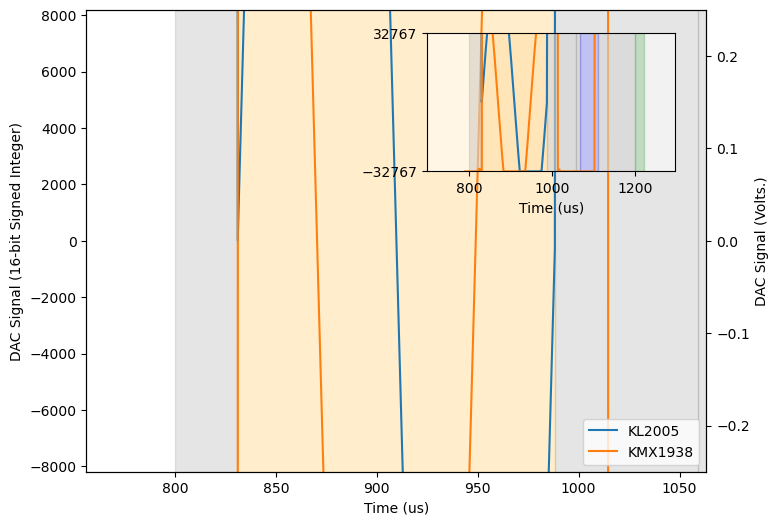

In [7]:
from kickercontrol import Scan

from kickercontrol.device import (KMX1938, KMX1965, KNY1938,
                                  KNY1965,KL2005)

scan_output = Scan([KL2005, KMX1938],
        scan_vectors=[np.arange(3), np.arange(3)],
        oscillators = ['sin', 'cos'],
        oscillator_variables=[{"V2": 0},{"V2": 0}],
        scan_variables=["V3", "V3"],
        write_dac = False,
        all_messages=False,
        display = True,
        beamline = '2',
        wait_time=1,
        relative_scan = True)


## Preset Scans and Functions

### Intra-Train Signal

Multi-Dimensional Signal Generator

In [10]:
from kickercontrol.main import SignalGenerator

scan_output = SignalGenerator(kicker_devices=[KL2005, KL2005],
                oscillators=['sin', 'cos'],
                oscillator_variables=[{"V3": 0.15},{"V3": 0.15}],
                beamline = '2',
                all_messages=False,
                display = True
            )

TypeError: Scan() got multiple values for argument 'scan_vectors'

### Inter-Train Scan

Inter-Train Scan of flat-top intra-train signal

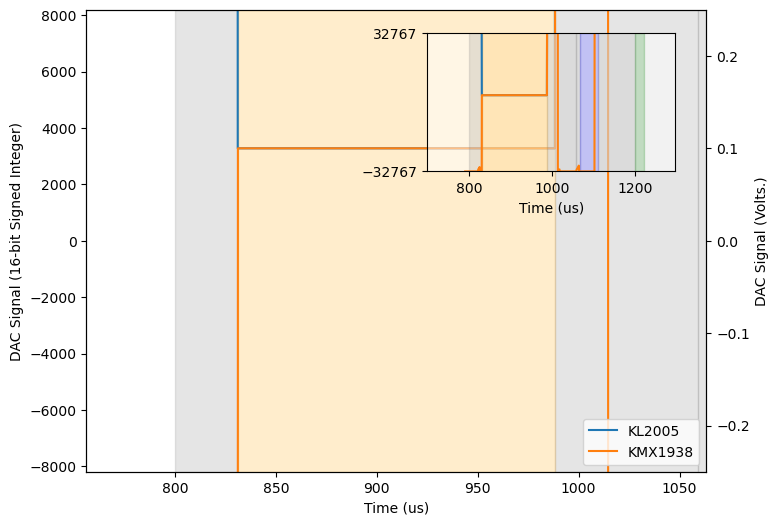

In [ ]:
from kickercontrol.main import MacroScan

scan_output = MacroScan([KL2005, KMX1938],
            scan_vectors = [np.linspace(-0.1,0.1,5), np.linspace(-.1,.1,5)],
            write_dac = False,
            all_messages=False,
            display = True,
            beamline = '2'
            )

### Single Kicker Scan

### Transverse Pointing Scan

### Sine Scan

### Ramp Scan

### Transverse Spiral

## **[WIP]** Optimisation